# Обучение модели общей классификации резюме

Ноутбук посвящен обучению модели, которая определяет общую профессиональную категорию кандидата по тексту резюме.

Основной акцент сделан на embedding-based подходах. TF-IDF baseline обучен в отдельном ноутбуке `00_train_tfidf_baseline.ipynb`.

В рамках экспериментов проверяются:

- классификаторы поверх `SentenceTransformer` embeddings;
- подбор гиперпараметров для `LinearSVC` и `LogisticRegression`;
- chunked embeddings для длинных резюме;
- гибридный вариант `BGE embeddings + TF-IDF/SVD`;
- ансамбль embeddings `BGE + MPNet`;
- дополнительная кросс-валидация финальных кандидатов.

## Импорты и настройка путей

In [1]:
from pathlib import Path
import time
import warnings
from tqdm.auto import tqdm

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sentence_transformers import SentenceTransformer

from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    make_scorer,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")

In [2]:
BASE_DIR = Path(".").resolve()

DATA_DIR = BASE_DIR / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
DATA_PATH = PROCESSED_DATA_DIR / "resume_dataset.csv"

REPORTS_DIR = BASE_DIR / "experiments" / "reports"
MODELS_DIR = BASE_DIR / "app" / "models"
EMBEDDING_MODEL_DIR = MODELS_DIR / "embedding_model"

DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
EMBEDDING_MODEL_DIR.mkdir(parents=True, exist_ok=True)


print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Processed data directory:", PROCESSED_DATA_DIR)
print("Dataset path:", DATA_PATH)
print("Reports directory:", REPORTS_DIR)
print("Models directory:", EMBEDDING_MODEL_DIR)

Base directory: /content
Data directory: /content/data
Processed data directory: /content/data/processed
Dataset path: /content/data/processed/resume_dataset.csv
Reports directory: /content/experiments/reports
Models directory: /content/app/models/embedding_model


## Загрузка и первичная очистка данных

Остаются только текст резюме и целевая категория, а также удаляются пустые значения, слишком короткие тексты и дубликаты.


In [3]:
df = pd.read_csv(DATA_PATH)

df = df[["resume_text", "target_role"]].dropna()
df["resume_text"] = df["resume_text"].astype(str).str.strip()
df["target_role"] = df["target_role"].astype(str).str.strip()

df = df[df["resume_text"].str.len() > 100]
df = df.drop_duplicates(subset=["resume_text", "target_role"])

print(df.shape)
df.head()

(2481, 2)


,resume_text,target_role
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\n\nHR ADM...,HR
1,"HR SPECIALIST, US HR OPERATIONS Summary ...",HR
2,HR DIRECTOR Summary Over 20 years e...,HR
3,"HR SPECIALIST Summary Dedicated, Driv...",HR
4,HR MANAGER Skill Highlights ...,HR


## Анализ распределения классов

In [4]:
class_counts = df["target_role"].value_counts()
class_counts

,count
target_role,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,119
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,117
FITNESS,117
SALES,116


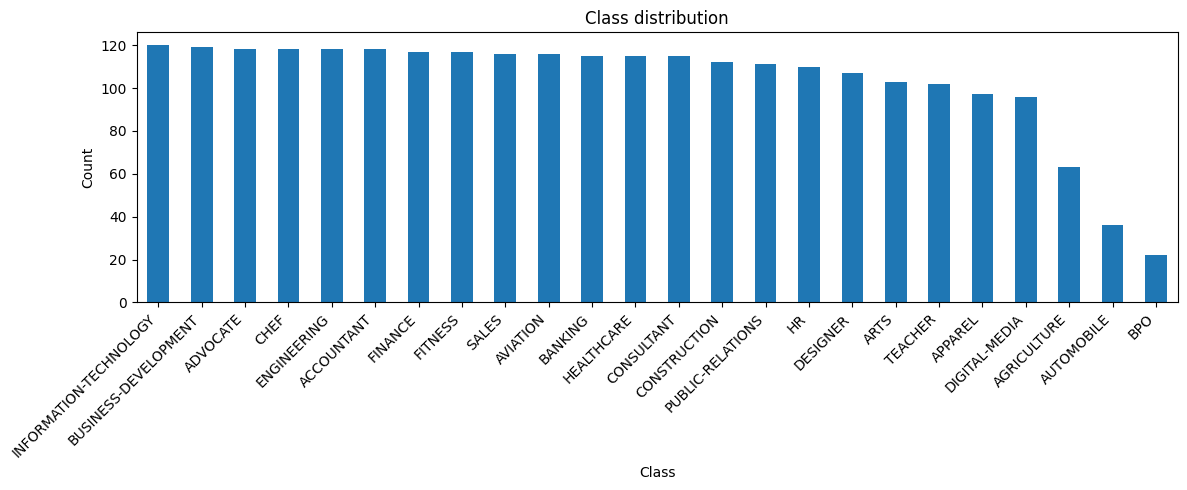

In [5]:
plt.figure(figsize=(12, 5))
class_counts.plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Разделение данных на train/test


In [6]:
X = df["resume_text"].tolist()
y = df["target_role"].tolist()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train_texts, X_test_texts, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded,
)

len(X_train_texts), len(X_test_texts), len(label_encoder.classes_)

(1984, 497, 24)

## Функция оценки качества

Функция считает основные метрики качества модели:

- `accuracy`;
- `macro_f1`;
- `weighted_f1`;
- `precision_macro`;
- `recall_macro`.

Основной метрикой сравнения выбрана `macro_f1`, так как она одинаково учитывает качество по каждому классу.


In [8]:
def evaluate_predictions(model_name, y_true_encoded, y_pred_encoded, label_encoder):
    y_true = label_encoder.inverse_transform(y_true_encoded)
    y_pred = label_encoder.inverse_transform(y_pred_encoded)

    metrics = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }

    print(model_name)
    print(metrics)
    print("\n", classification_report(y_true, y_pred, zero_division=0))

    return metrics

## Сравнение embedding-моделей

На этом этапе тестируется подход к классификации резюме на основе sentence embeddings.  
Embedding-модель преобразует текст резюме в плотный числовой вектор, который отражает смысловое содержание текста.

В эксперименте сравниваются три предобученные SentenceTransformer-модели:

- `sentence-transformers/all-MiniLM-L6-v2`
- `sentence-transformers/all-mpnet-base-v2`
- `BAAI/bge-small-en-v1.5`

Для каждой модели тексты обучающей и тестовой выборок преобразуются в embedding-векторы. Затем поверх этих векторов обучаются два классификатора:

- `LogisticRegression`
- `LinearSVC`

Цель этапа — выбрать наиболее качественную комбинацию embedding-модели и классификатора для дальнейшего использования в сервисе.

In [9]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"

print("Device:", device)
print("CUDA available:", torch.cuda.is_available())

Device: cuda
CUDA available: True


In [10]:
embedding_models = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "sentence-transformers/all-mpnet-base-v2",
    "BAAI/bge-small-en-v1.5",
]

embedding_results = []
trained_embedding_models = {}

for emb_model_name in embedding_models:
    print("Embedding model:", emb_model_name)

    start_time = time.time()

    emb_model = SentenceTransformer(
        emb_model_name,
        device=device,
    )

    X_train_emb = emb_model.encode(
        X_train_texts,
        batch_size=32 if device != "cpu" else 16,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
        device=device,
    )

    X_test_emb = emb_model.encode(
        X_test_texts,
        batch_size=32 if device != "cpu" else 16,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
        device=device,
    )

    classifiers = {
        "logreg": LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
        "linearsvc": LinearSVC(
            class_weight="balanced",
            random_state=42,
        ),
    }

    for clf_name, clf in classifiers.items():
        model_name = f"{emb_model_name} + {clf_name}"

        clf.fit(X_train_emb, y_train)
        y_pred = clf.predict(X_test_emb)

        metrics = evaluate_predictions(
            model_name=model_name,
            y_true_encoded=y_test,
            y_pred_encoded=y_pred,
            label_encoder=label_encoder,
        )

        metrics["embedding_model"] = emb_model_name
        metrics["classifier"] = clf_name
        metrics["device"] = device
        metrics["train_eval_seconds"] = round(time.time() - start_time, 2)

        embedding_results.append(metrics)
        trained_embedding_models[model_name] = {
            "embedding_model_name": emb_model_name,
            "classifier": clf,
            "device": device,
        }

embedding_results_df = pd.DataFrame(embedding_results).sort_values(
    "macro_f1",
    ascending=False,
)

embedding_results_df

Embedding model: sentence-transformers/all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

BAAI/bge-small-en-v1.5 + logreg
{'model_name': 'BAAI/bge-small-en-v1.5 + logreg', 'accuracy': 0.7847082494969819, 'macro_f1': 0.7423524242307495, 'weighted_f1': 0.7723919134584979, 'precision_macro': 0.7586942621563867, 'recall_macro': 0.7545046589883547}

                         precision    recall  f1-score   support

            ACCOUNTANT       0.82      0.96      0.88        24
              ADVOCATE       0.82      0.75      0.78        24
           AGRICULTURE       0.91      0.77      0.83        13
               APPAREL       0.50      0.21      0.30        19
                  ARTS       0.71      0.24      0.36        21
            AUTOMOBILE       0.57      0.57      0.57         7
              AVIATION       0.86      0.83      0.84        23
               BANKING       0.83      0.65      0.73        23
                   BPO       0.17      0.25      0.20         4
  BUSINESS-DEVELOPMENT       0.83      1.00      0.91        24
                  CHEF       0.91    

,model_name,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,embedding_model,classifier,device,train_eval_seconds
5,BAAI/bge-small-en-v1.5 + linearsvc,0.802817,0.765127,0.794366,0.769748,0.775410,BAAI/bge-small-en-v1.5,linearsvc,cuda,42.82
3,sentence-transformers/all-mpnet-base-v2 + line...,0.788732,0.759995,0.784145,0.774040,0.762846,sentence-transformers/all-mpnet-base-v2,linearsvc,cuda,79.82
4,BAAI/bge-small-en-v1.5 + logreg,0.784708,0.742352,0.772392,0.758694,0.754505,BAAI/bge-small-en-v1.5,logreg,cuda,41.58
2,sentence-transformers/all-mpnet-base-v2 + logreg,0.768612,0.735408,0.761643,0.750830,0.740480,sentence-transformers/all-mpnet-base-v2,logreg,cuda,77.34
1,sentence-transformers/all-MiniLM-L6-v2 + linea...,0.740443,0.694810,0.730621,0.709189,0.704700,sentence-transformers/all-MiniLM-L6-v2,linearsvc,cuda,24.56
0,sentence-transformers/all-MiniLM-L6-v2 + logreg,0.730382,0.692531,0.719919,0.703518,0.707881,sentence-transformers/all-MiniLM-L6-v2,logreg,cuda,23.13




По результатам первичного сравнения для дальнейших экспериментов выбирается модель `BAAI/bge-small-en-v1.5`.


In [11]:
best_embedding_model_name = "BAAI/bge-small-en-v1.5"
print("Best embedding model:", best_embedding_model_name)

Best embedding model: BAAI/bge-small-en-v1.5


## Генерация embeddings выбранной моделью


In [12]:
best_embedding_model = SentenceTransformer(
    best_embedding_model_name,
    device=device,
)

print("Encoding train texts...")
X_train_emb_best = best_embedding_model.encode(
    X_train_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    device=device,
)

print("Encoding test texts...")
X_test_emb_best = best_embedding_model.encode(
    X_test_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    device=device,
)

print("Train embeddings:", X_train_emb_best.shape)
print("Test embeddings:", X_test_emb_best.shape)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding train texts...


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Encoding test texts...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Train embeddings: (1984, 384)
Test embeddings: (497, 384)


## Подбор гиперпараметров для LinearSVC

In [13]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

macro_f1_scorer = make_scorer(
    f1_score,
    average="macro",
)

svc_param_grid = {
    "C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "class_weight": [None, "balanced"],
    "loss": ["squared_hinge"],
}

svc_grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=svc_param_grid,
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

svc_grid_search.fit(X_train_emb_best, y_train)

print("Best params:", svc_grid_search.best_params_)
print("Best CV macro F1:", svc_grid_search.best_score_)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best params: {'C': 1, 'class_weight': 'balanced', 'loss': 'squared_hinge'}
Best CV macro F1: 0.7135199486638462


In [14]:
best_svc = svc_grid_search.best_estimator_

y_pred_svc_tuned = best_svc.predict(X_test_emb_best)

svc_tuned_metrics = evaluate_predictions(
    model_name="BAAI/bge-small-en-v1.5 + tuned LinearSVC",
    y_true_encoded=y_test,
    y_pred_encoded=y_pred_svc_tuned,
    label_encoder=label_encoder,
)

svc_tuned_metrics["embedding_model"] = best_embedding_model_name
svc_tuned_metrics["classifier"] = "tuned LinearSVC"
svc_tuned_metrics["best_params"] = str(svc_grid_search.best_params_)
svc_tuned_metrics["cv_macro_f1"] = svc_grid_search.best_score_

svc_tuned_metrics

BAAI/bge-small-en-v1.5 + tuned LinearSVC
{'model_name': 'BAAI/bge-small-en-v1.5 + tuned LinearSVC', 'accuracy': 0.8028169014084507, 'macro_f1': 0.7651267907516935, 'weighted_f1': 0.7943663820530134, 'precision_macro': 0.7697482131077669, 'recall_macro': 0.7754101939885693}

                         precision    recall  f1-score   support

            ACCOUNTANT       0.85      0.96      0.90        24
              ADVOCATE       0.91      0.83      0.87        24
           AGRICULTURE       0.67      0.77      0.71        13
               APPAREL       0.62      0.26      0.37        19
                  ARTS       0.67      0.38      0.48        21
            AUTOMOBILE       0.43      0.43      0.43         7
              AVIATION       0.86      0.78      0.82        23
               BANKING       0.81      0.74      0.77        23
                   BPO       0.40      0.50      0.44         4
  BUSINESS-DEVELOPMENT       0.86      1.00      0.92        24
                  C

{'model_name': 'BAAI/bge-small-en-v1.5 + tuned LinearSVC',
 'accuracy': 0.8028169014084507,
 'macro_f1': 0.7651267907516935,
 'weighted_f1': 0.7943663820530134,
 'precision_macro': 0.7697482131077669,
 'recall_macro': 0.7754101939885693,
 'embedding_model': 'BAAI/bge-small-en-v1.5',
 'classifier': 'tuned LinearSVC',
 'best_params': "{'C': 1, 'class_weight': 'balanced', 'loss': 'squared_hinge'}",
 'cv_macro_f1': np.float64(0.7135199486638462)}

## Подбор гиперпараметров для LogisticRegression


In [15]:
logreg_param_grid = {
    "C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10],
    "class_weight": [None, "balanced"],
    "solver": ["lbfgs"],
}

logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
    ),
    param_grid=logreg_param_grid,
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

logreg_grid_search.fit(X_train_emb_best, y_train)

print("Best params:", logreg_grid_search.best_params_)
print("Best CV macro F1:", logreg_grid_search.best_score_)

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best params: {'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Best CV macro F1: 0.7207019818280407


In [16]:
best_logreg = logreg_grid_search.best_estimator_

y_pred_logreg_tuned = best_logreg.predict(X_test_emb_best)

logreg_tuned_metrics = evaluate_predictions(
    model_name="BAAI/bge-small-en-v1.5 + tuned LogisticRegression",
    y_true_encoded=y_test,
    y_pred_encoded=y_pred_logreg_tuned,
    label_encoder=label_encoder,
)

logreg_tuned_metrics["embedding_model"] = best_embedding_model_name
logreg_tuned_metrics["classifier"] = "tuned LogisticRegression"
logreg_tuned_metrics["best_params"] = str(logreg_grid_search.best_params_)
logreg_tuned_metrics["cv_macro_f1"] = logreg_grid_search.best_score_

logreg_tuned_metrics

BAAI/bge-small-en-v1.5 + tuned LogisticRegression
{'model_name': 'BAAI/bge-small-en-v1.5 + tuned LogisticRegression', 'accuracy': 0.8048289738430584, 'macro_f1': 0.7675004027050618, 'weighted_f1': 0.8015121825761502, 'precision_macro': 0.7709897708788889, 'recall_macro': 0.7738269167903035}

                         precision    recall  f1-score   support

            ACCOUNTANT       0.85      0.96      0.90        24
              ADVOCATE       0.87      0.83      0.85        24
           AGRICULTURE       0.62      0.77      0.69        13
               APPAREL       0.70      0.37      0.48        19
                  ARTS       0.56      0.48      0.51        21
            AUTOMOBILE       0.44      0.57      0.50         7
              AVIATION       0.90      0.78      0.84        23
               BANKING       0.76      0.70      0.73        23
                   BPO       0.25      0.25      0.25         4
  BUSINESS-DEVELOPMENT       0.89      1.00      0.94        24
 

{'model_name': 'BAAI/bge-small-en-v1.5 + tuned LogisticRegression',
 'accuracy': 0.8048289738430584,
 'macro_f1': 0.7675004027050618,
 'weighted_f1': 0.8015121825761502,
 'precision_macro': 0.7709897708788889,
 'recall_macro': 0.7738269167903035,
 'embedding_model': 'BAAI/bge-small-en-v1.5',
 'classifier': 'tuned LogisticRegression',
 'best_params': "{'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}",
 'cv_macro_f1': np.float64(0.7207019818280407)}

## Сравнение baseline и embedding-подходов


In [17]:
baseline_results = [
    {
        "model_name": "TF-IDF + LogisticRegression baseline",
        "accuracy": 0.6579,
        "macro_f1": 0.6276,
        "weighted_f1": 0.6448,
        "precision_macro": 0.6702,
        "recall_macro": 0.63,
        "embedding_model": None,
        "classifier": "LogisticRegression",
        "device": None,
        "train_eval_seconds": None,
        "best_params": None,
        "cv_macro_f1": None,
    }
]

tuned_results = [
    svc_tuned_metrics,
    logreg_tuned_metrics,
]

all_results_df = pd.concat(
    [
        pd.DataFrame(baseline_results),
        embedding_results_df,
        pd.DataFrame(tuned_results),
    ],
    ignore_index=True,
)

all_results_df = all_results_df.sort_values("macro_f1", ascending=False)

all_results_df

,model_name,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,embedding_model,classifier,device,train_eval_seconds,best_params,cv_macro_f1
8,BAAI/bge-small-en-v1.5 + tuned LogisticRegression,0.804829,0.767500,0.801512,0.770990,0.773827,BAAI/bge-small-en-v1.5,tuned LogisticRegression,NaN,NaN,"{'C': 10, 'class_weight': 'balanced', 'solver'...",0.720702
7,BAAI/bge-small-en-v1.5 + tuned LinearSVC,0.802817,0.765127,0.794366,0.769748,0.775410,BAAI/bge-small-en-v1.5,tuned LinearSVC,NaN,NaN,"{'C': 1, 'class_weight': 'balanced', 'loss': '...",0.713520
1,BAAI/bge-small-en-v1.5 + linearsvc,0.802817,0.765127,0.794366,0.769748,0.775410,BAAI/bge-small-en-v1.5,linearsvc,cuda,42.82,NaN,NaN
2,sentence-transformers/all-mpnet-base-v2 + line...,0.788732,0.759995,0.784145,0.774040,0.762846,sentence-transformers/all-mpnet-base-v2,linearsvc,cuda,79.82,NaN,NaN
3,BAAI/bge-small-en-v1.5 + logreg,0.784708,0.742352,0.772392,0.758694,0.754505,BAAI/bge-small-en-v1.5,logreg,cuda,41.58,NaN,NaN
4,sentence-transformers/all-mpnet-base-v2 + logreg,0.768612,0.735408,0.761643,0.750830,0.740480,sentence-transformers/all-mpnet-base-v2,logreg,cuda,77.34,NaN,NaN
5,sentence-transformers/all-MiniLM-L6-v2 + linea...,0.740443,0.694810,0.730621,0.709189,0.704700,sentence-transformers/all-MiniLM-L6-v2,linearsvc,cuda,24.56,NaN,NaN
6,sentence-transformers/all-MiniLM-L6-v2 + logreg,0.730382,0.692531,0.719919,0.703518,0.707881,sentence-transformers/all-MiniLM-L6-v2,logreg,cuda,23.13,NaN,NaN
0,TF-IDF + LogisticRegression baseline,0.657900,0.627600,0.644800,0.670200,0.630000,None,LogisticRegression,None,NaN,None,NaN


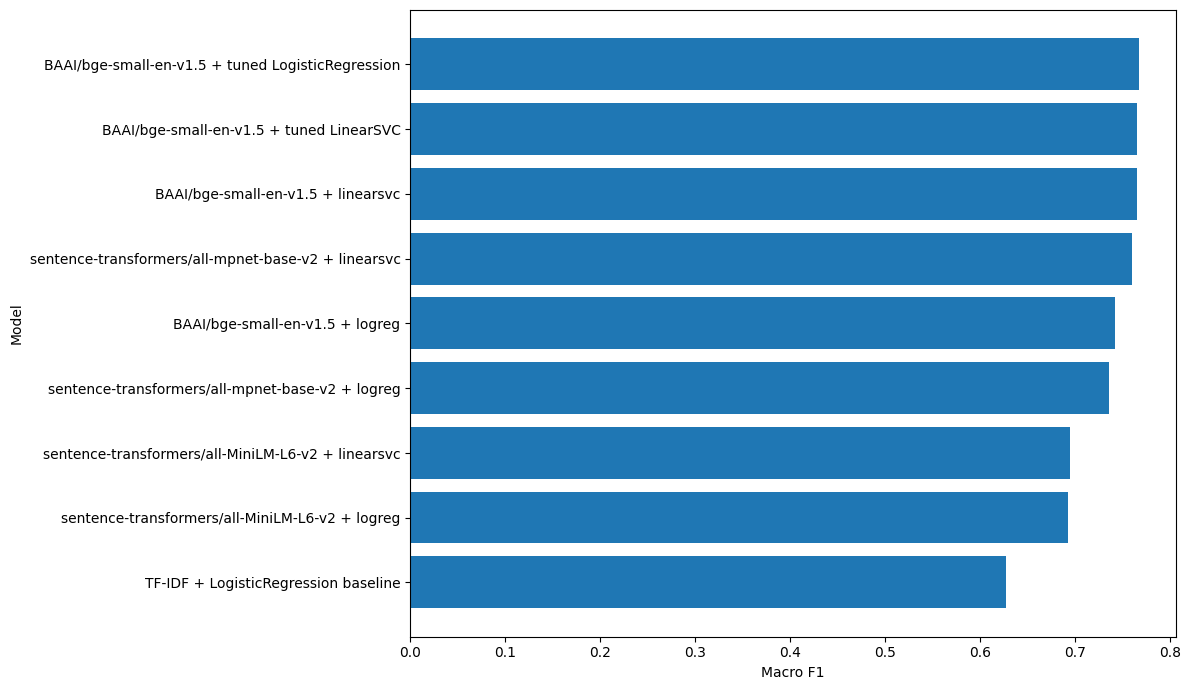

In [20]:
plot_df = all_results_df.sort_values("macro_f1", ascending=True)

plt.figure(figsize=(12, 7))
plt.barh(plot_df["model_name"], plot_df["macro_f1"])
plt.xlabel("Macro F1")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## Эксперимент с chunked embeddings


In [32]:
def split_text_into_chunks(text, max_words=180, overlap_words=40):
    words = str(text).split()

    if len(words) <= max_words:
        return [" ".join(words)]

    chunks = []
    start = 0

    while start < len(words):
        end = start + max_words
        chunk = " ".join(words[start:end])
        chunks.append(chunk)

        if end >= len(words):
            break

        start = end - overlap_words

    return chunks

In [33]:
chunk_embedding_model_name = "BAAI/bge-small-en-v1.5"

chunk_embedding_model = SentenceTransformer(
    chunk_embedding_model_name,
    device=device,
)

def encode_texts_with_chunking(
    texts,
    model,
    max_words=180,
    overlap_words=40,
    batch_size=32,
):
    final_embeddings = []

    for text in tqdm(texts):
        chunks = split_text_into_chunks(
            text=text,
            max_words=max_words,
            overlap_words=overlap_words,
        )

        chunk_embeddings = model.encode(
            chunks,
            batch_size=batch_size,
            show_progress_bar=False,
            convert_to_numpy=True,
            normalize_embeddings=True,
            device=device,
        )

        text_embedding = chunk_embeddings.mean(axis=0)

        norm = np.linalg.norm(text_embedding)
        if norm > 0:
            text_embedding = text_embedding / norm

        final_embeddings.append(text_embedding)

    return np.vstack(final_embeddings)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [34]:
X_train_emb_chunked = encode_texts_with_chunking(
    X_train_texts,
    model=chunk_embedding_model,
    max_words=180,
    overlap_words=40,
    batch_size=32,
)

X_test_emb_chunked = encode_texts_with_chunking(
    X_test_texts,
    model=chunk_embedding_model,
    max_words=180,
    overlap_words=40,
    batch_size=32,
)

print(X_train_emb_chunked.shape)
print(X_test_emb_chunked.shape)

  0%|          | 0/1984 [00:00<?, ?it/s]

  0%|          | 0/497 [00:00<?, ?it/s]

(1984, 384)
(497, 384)


In [35]:
chunk_logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
    ),
    param_grid={
        "C": [0.1, 0.3, 1, 3, 10, 30],
        "class_weight": [None, "balanced"],
        "solver": ["lbfgs"],
    },
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

chunk_logreg_grid_search.fit(X_train_emb_chunked, y_train)

print("Best params:", chunk_logreg_grid_search.best_params_)
print("Best CV macro F1:", chunk_logreg_grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'C': 30, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Best CV macro F1: 0.6223233400141444


In [36]:
best_chunk_logreg = chunk_logreg_grid_search.best_estimator_

y_pred_chunk_logreg = best_chunk_logreg.predict(X_test_emb_chunked)

chunk_logreg_metrics = evaluate_predictions(
    model_name="BGE chunked embeddings + tuned LogisticRegression",
    y_true_encoded=y_test,
    y_pred_encoded=y_pred_chunk_logreg,
    label_encoder=label_encoder,
)

chunk_logreg_metrics["embedding_model"] = chunk_embedding_model_name
chunk_logreg_metrics["classifier"] = "chunked tuned LogisticRegression"
chunk_logreg_metrics["best_params"] = str(chunk_logreg_grid_search.best_params_)
chunk_logreg_metrics["cv_macro_f1"] = chunk_logreg_grid_search.best_score_

chunk_logreg_metrics

BGE chunked embeddings + tuned LogisticRegression
{'model_name': 'BGE chunked embeddings + tuned LogisticRegression', 'accuracy': 0.6619718309859155, 'macro_f1': 0.6445229844177399, 'weighted_f1': 0.6637400142805201, 'precision_macro': 0.646757540220868, 'recall_macro': 0.653134591857418}

                         precision    recall  f1-score   support

            ACCOUNTANT       0.56      0.75      0.64        24
              ADVOCATE       0.60      0.62      0.61        24
           AGRICULTURE       0.59      0.77      0.67        13
               APPAREL       0.53      0.47      0.50        19
                  ARTS       0.47      0.43      0.45        21
            AUTOMOBILE       0.31      0.57      0.40         7
              AVIATION       0.78      0.78      0.78        23
               BANKING       0.68      0.65      0.67        23
                   BPO       0.33      0.50      0.40         4
  BUSINESS-DEVELOPMENT       0.70      0.67      0.68        24
   

{'model_name': 'BGE chunked embeddings + tuned LogisticRegression',
 'accuracy': 0.6619718309859155,
 'macro_f1': 0.6445229844177399,
 'weighted_f1': 0.6637400142805201,
 'precision_macro': 0.646757540220868,
 'recall_macro': 0.653134591857418,
 'embedding_model': 'BAAI/bge-small-en-v1.5',
 'classifier': 'chunked tuned LogisticRegression',
 'best_params': "{'C': 30, 'class_weight': 'balanced', 'solver': 'lbfgs'}",
 'cv_macro_f1': np.float64(0.6223233400141444)}

## Гибридный вариант: embeddings + TF-IDF/SVD

In [23]:
tfidf_for_hybrid = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_tfidf = tfidf_for_hybrid.fit_transform(X_train_texts)
X_test_tfidf = tfidf_for_hybrid.transform(X_test_texts)

svd = TruncatedSVD(
    n_components=300,
    random_state=42,
)

X_train_svd = svd.fit_transform(X_train_tfidf)
X_test_svd = svd.transform(X_test_tfidf)

scaler = StandardScaler()

X_train_svd_scaled = scaler.fit_transform(X_train_svd)
X_test_svd_scaled = scaler.transform(X_test_svd)

X_train_hybrid = np.hstack([X_train_emb_best, X_train_svd_scaled])
X_test_hybrid = np.hstack([X_test_emb_best, X_test_svd_scaled])

print(X_train_hybrid.shape)
print(X_test_hybrid.shape)

(1984, 684)
(497, 684)


In [24]:
hybrid_logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
    ),
    param_grid={
        "C": [0.1, 0.3, 1, 3, 10],
        "class_weight": [None, "balanced"],
        "solver": ["lbfgs"],
    },
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

hybrid_logreg_grid_search.fit(X_train_hybrid, y_train)

print("Best params:", hybrid_logreg_grid_search.best_params_)
print("Best CV macro F1:", hybrid_logreg_grid_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 0.1, 'class_weight': None, 'solver': 'lbfgs'}
Best CV macro F1: 0.5984189978914298


In [25]:
best_hybrid_logreg = hybrid_logreg_grid_search.best_estimator_

y_pred_hybrid_logreg = best_hybrid_logreg.predict(X_test_hybrid)

hybrid_logreg_metrics = evaluate_predictions(
    model_name="BGE embeddings + TF-IDF/SVD + tuned LogisticRegression",
    y_true_encoded=y_test,
    y_pred_encoded=y_pred_hybrid_logreg,
    label_encoder=label_encoder,
)

hybrid_logreg_metrics["embedding_model"] = "BAAI/bge-small-en-v1.5 + TF-IDF/SVD"
hybrid_logreg_metrics["classifier"] = "hybrid tuned LogisticRegression"
hybrid_logreg_metrics["best_params"] = str(hybrid_logreg_grid_search.best_params_)
hybrid_logreg_metrics["cv_macro_f1"] = hybrid_logreg_grid_search.best_score_

hybrid_logreg_metrics

BGE embeddings + TF-IDF/SVD + tuned LogisticRegression
{'model_name': 'BGE embeddings + TF-IDF/SVD + tuned LogisticRegression', 'accuracy': 0.6579476861167002, 'macro_f1': 0.6109879697316102, 'weighted_f1': 0.6446094731101013, 'precision_macro': 0.6243192321678448, 'recall_macro': 0.6188177034000832}

                         precision    recall  f1-score   support

            ACCOUNTANT       0.58      0.79      0.67        24
              ADVOCATE       0.52      0.54      0.53        24
           AGRICULTURE       0.70      0.54      0.61        13
               APPAREL       0.42      0.26      0.32        19
                  ARTS       0.46      0.29      0.35        21
            AUTOMOBILE       0.50      0.29      0.36         7
              AVIATION       0.80      0.70      0.74        23
               BANKING       0.64      0.70      0.67        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.63      0.79      0.70  

{'model_name': 'BGE embeddings + TF-IDF/SVD + tuned LogisticRegression',
 'accuracy': 0.6579476861167002,
 'macro_f1': 0.6109879697316102,
 'weighted_f1': 0.6446094731101013,
 'precision_macro': 0.6243192321678448,
 'recall_macro': 0.6188177034000832,
 'embedding_model': 'BAAI/bge-small-en-v1.5 + TF-IDF/SVD',
 'classifier': 'hybrid tuned LogisticRegression',
 'best_params': "{'C': 0.1, 'class_weight': None, 'solver': 'lbfgs'}",
 'cv_macro_f1': np.float64(0.5984189978914298)}

## Ансамбль embeddings BGE + MPNet


In [26]:
mpnet_model_name = "sentence-transformers/all-mpnet-base-v2"

mpnet_model = SentenceTransformer(
    mpnet_model_name,
    device=device,
)

X_train_emb_mpnet = mpnet_model.encode(
    X_train_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    device=device,
)

X_test_emb_mpnet = mpnet_model.encode(
    X_test_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
    device=device,
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [27]:
X_train_bge_mpnet = np.hstack([X_train_emb_best, X_train_emb_mpnet])
X_test_bge_mpnet = np.hstack([X_test_emb_best, X_test_emb_mpnet])

print(X_train_bge_mpnet.shape)
print(X_test_bge_mpnet.shape)

(1984, 1152)
(497, 1152)


In [28]:
ensemble_logreg_grid_search = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=5000,
        random_state=42,
        n_jobs=-1,
    ),
    param_grid={
        "C": [0.1, 0.3, 1, 3, 10],
        "class_weight": [None, "balanced"],
        "solver": ["lbfgs"],
    },
    scoring=macro_f1_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2,
)

ensemble_logreg_grid_search.fit(X_train_bge_mpnet, y_train)

print("Best params:", ensemble_logreg_grid_search.best_params_)
print("Best CV macro F1:", ensemble_logreg_grid_search.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'C': 3, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Best CV macro F1: 0.7088244959654688


In [29]:
best_ensemble_logreg = ensemble_logreg_grid_search.best_estimator_

y_pred_ensemble_logreg = best_ensemble_logreg.predict(X_test_bge_mpnet)

ensemble_logreg_metrics = evaluate_predictions(
    model_name="BGE + MPNet embeddings + tuned LogisticRegression",
    y_true_encoded=y_test,
    y_pred_encoded=y_pred_ensemble_logreg,
    label_encoder=label_encoder,
)

ensemble_logreg_metrics["embedding_model"] = "BAAI/bge-small-en-v1.5 + all-mpnet-base-v2"
ensemble_logreg_metrics["classifier"] = "ensemble tuned LogisticRegression"
ensemble_logreg_metrics["best_params"] = str(ensemble_logreg_grid_search.best_params_)
ensemble_logreg_metrics["cv_macro_f1"] = ensemble_logreg_grid_search.best_score_

ensemble_logreg_metrics

BGE + MPNet embeddings + tuned LogisticRegression
{'model_name': 'BGE + MPNet embeddings + tuned LogisticRegression', 'accuracy': 0.8088531187122736, 'macro_f1': 0.7819678828933944, 'weighted_f1': 0.8051253499332476, 'precision_macro': 0.7852514410428952, 'recall_macro': 0.7873488845885871}

                         precision    recall  f1-score   support

            ACCOUNTANT       0.85      0.96      0.90        24
              ADVOCATE       0.91      0.83      0.87        24
           AGRICULTURE       0.83      0.77      0.80        13
               APPAREL       0.53      0.47      0.50        19
                  ARTS       0.62      0.38      0.47        21
            AUTOMOBILE       0.57      0.57      0.57         7
              AVIATION       0.80      0.87      0.83        23
               BANKING       0.81      0.74      0.77        23
                   BPO       0.40      0.50      0.44         4
  BUSINESS-DEVELOPMENT       0.96      0.92      0.94        24
 

{'model_name': 'BGE + MPNet embeddings + tuned LogisticRegression',
 'accuracy': 0.8088531187122736,
 'macro_f1': 0.7819678828933944,
 'weighted_f1': 0.8051253499332476,
 'precision_macro': 0.7852514410428952,
 'recall_macro': 0.7873488845885871,
 'embedding_model': 'BAAI/bge-small-en-v1.5 + all-mpnet-base-v2',
 'classifier': 'ensemble tuned LogisticRegression',
 'best_params': "{'C': 3, 'class_weight': 'balanced', 'solver': 'lbfgs'}",
 'cv_macro_f1': np.float64(0.7088244959654688)}

## Итоговое сравнение моделей


In [37]:
additional_results = [
    chunk_logreg_metrics,
    hybrid_logreg_metrics,
    ensemble_logreg_metrics,
]

final_results_df = pd.concat(
    [
        all_results_df,
        pd.DataFrame(additional_results),
    ],
    ignore_index=True,
)

final_results_df = final_results_df.sort_values("macro_f1", ascending=False)

final_results_df

,model_name,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro,embedding_model,classifier,device,train_eval_seconds,best_params,cv_macro_f1
11,BGE + MPNet embeddings + tuned LogisticRegression,0.808853,0.781968,0.805125,0.785251,0.787349,BAAI/bge-small-en-v1.5 + all-mpnet-base-v2,ensemble tuned LogisticRegression,NaN,NaN,"{'C': 3, 'class_weight': 'balanced', 'solver':...",0.708824
0,BAAI/bge-small-en-v1.5 + tuned LogisticRegression,0.804829,0.767500,0.801512,0.770990,0.773827,BAAI/bge-small-en-v1.5,tuned LogisticRegression,NaN,NaN,"{'C': 10, 'class_weight': 'balanced', 'solver'...",0.720702
2,BAAI/bge-small-en-v1.5 + linearsvc,0.802817,0.765127,0.794366,0.769748,0.775410,BAAI/bge-small-en-v1.5,linearsvc,cuda,42.82,NaN,NaN
1,BAAI/bge-small-en-v1.5 + tuned LinearSVC,0.802817,0.765127,0.794366,0.769748,0.775410,BAAI/bge-small-en-v1.5,tuned LinearSVC,NaN,NaN,"{'C': 1, 'class_weight': 'balanced', 'loss': '...",0.713520
3,sentence-transformers/all-mpnet-base-v2 + line...,0.788732,0.759995,0.784145,0.774040,0.762846,sentence-transformers/all-mpnet-base-v2,linearsvc,cuda,79.82,NaN,NaN
4,BAAI/bge-small-en-v1.5 + logreg,0.784708,0.742352,0.772392,0.758694,0.754505,BAAI/bge-small-en-v1.5,logreg,cuda,41.58,NaN,NaN
5,sentence-transformers/all-mpnet-base-v2 + logreg,0.768612,0.735408,0.761643,0.750830,0.740480,sentence-transformers/all-mpnet-base-v2,logreg,cuda,77.34,NaN,NaN
6,sentence-transformers/all-MiniLM-L6-v2 + linea...,0.740443,0.694810,0.730621,0.709189,0.704700,sentence-transformers/all-MiniLM-L6-v2,linearsvc,cuda,24.56,NaN,NaN
7,sentence-transformers/all-MiniLM-L6-v2 + logreg,0.730382,0.692531,0.719919,0.703518,0.707881,sentence-transformers/all-MiniLM-L6-v2,logreg,cuda,23.13,NaN,NaN
9,BGE chunked embeddings + tuned LogisticRegression,0.661972,0.644523,0.663740,0.646758,0.653135,BAAI/bge-small-en-v1.5,chunked tuned LogisticRegression,NaN,NaN,"{'C': 30, 'class_weight': 'balanced', 'solver'...",0.622323


## Дополнительная кросс-валидация финальных кандидатов


In [38]:
def evaluate_cv_model(X_features, y, model, model_name, n_splits=5):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    rows = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X_features, y), start=1):
        X_train_fold = X_features[train_idx]
        X_test_fold = X_features[test_idx]

        y_train_fold = y[train_idx]
        y_test_fold = y[test_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred_fold = model.predict(X_test_fold)

        row = {
            "model_name": model_name,
            "fold": fold,
            "accuracy": accuracy_score(y_test_fold, y_pred_fold),
            "macro_f1": f1_score(y_test_fold, y_pred_fold, average="macro"),
            "weighted_f1": f1_score(y_test_fold, y_pred_fold, average="weighted"),
            "precision_macro": precision_score(
                y_test_fold,
                y_pred_fold,
                average="macro",
                zero_division=0,
            ),
            "recall_macro": recall_score(
                y_test_fold,
                y_pred_fold,
                average="macro",
                zero_division=0,
            ),
        }

        rows.append(row)

    return pd.DataFrame(rows)

In [39]:
bge_cv_model = LogisticRegression(
    C=10,
    class_weight="balanced",
    solver="lbfgs",
    max_iter=5000,
    random_state=42,
    n_jobs=-1,
)

bge_cv_results = evaluate_cv_model(
    X_features=X_train_emb_best,
    y=np.array(y_train),
    model=bge_cv_model,
    model_name="BGE + tuned LogisticRegression",
    n_splits=5,
)

bge_cv_results

,model_name,fold,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro
0,BGE + tuned LogisticRegression,1,0.785894,0.742940,0.780508,0.748346,0.747100
1,BGE + tuned LogisticRegression,2,0.788413,0.756727,0.784517,0.772632,0.754625
2,BGE + tuned LogisticRegression,3,0.735516,0.700034,0.727509,0.712569,0.707860
3,BGE + tuned LogisticRegression,4,0.750630,0.703680,0.746883,0.710789,0.711755
4,BGE + tuned LogisticRegression,5,0.744949,0.700130,0.743532,0.712200,0.699225


In [40]:
ensemble_cv_model = LogisticRegression(
    C=3,
    class_weight="balanced",
    solver="lbfgs",
    max_iter=5000,
    random_state=42,
    n_jobs=-1,
)

ensemble_cv_results = evaluate_cv_model(
    X_features=X_train_bge_mpnet,
    y=np.array(y_train),
    model=ensemble_cv_model,
    model_name="BGE + MPNet + tuned LogisticRegression",
    n_splits=5,
)

ensemble_cv_results

,model_name,fold,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro
0,BGE + MPNet + tuned LogisticRegression,1,0.778338,0.723978,0.772503,0.730083,0.728993
1,BGE + MPNet + tuned LogisticRegression,2,0.770781,0.718039,0.761903,0.724361,0.725863
2,BGE + MPNet + tuned LogisticRegression,3,0.745592,0.711551,0.739474,0.737879,0.716431
3,BGE + MPNet + tuned LogisticRegression,4,0.765743,0.724579,0.761245,0.744788,0.724868
4,BGE + MPNet + tuned LogisticRegression,5,0.727273,0.665976,0.719128,0.667243,0.673951


In [41]:
cv_comparison_df = pd.concat(
    [
        bge_cv_results,
        ensemble_cv_results,
    ],
    ignore_index=True,
)

cv_summary_df = (
    cv_comparison_df
    .groupby("model_name")
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        macro_f1_mean=("macro_f1", "mean"),
        macro_f1_std=("macro_f1", "std"),
        weighted_f1_mean=("weighted_f1", "mean"),
        weighted_f1_std=("weighted_f1", "std"),
        precision_macro_mean=("precision_macro", "mean"),
        recall_macro_mean=("recall_macro", "mean"),
    )
    .reset_index()
    .sort_values("macro_f1_mean", ascending=False)
)

cv_summary_df

,model_name,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std,precision_macro_mean,recall_macro_mean
1,BGE + tuned LogisticRegression,0.761081,0.024422,0.720702,0.027076,0.75659,0.024811,0.731307,0.724113
0,BGE + MPNet + tuned LogisticRegression,0.757545,0.020821,0.708824,0.024526,0.75085,0.021417,0.720871,0.714021


## Финальное обучение и сохранение модели

Сохраняются три артефакта:

- `embedding_classifier.pkl`
- `label_encoder.pkl`
- `metadata.pkl`

In [46]:
final_embedding_model_name = "BAAI/bge-small-en-v1.5"

final_classifier = LogisticRegression(
    C=10,
    class_weight="balanced",
    solver="lbfgs",
    max_iter=5000,
    random_state=42,
    n_jobs=-1,
)

final_classifier.fit(X_train_emb_best, y_train)

joblib.dump(final_classifier, EMBEDDING_MODEL_DIR / "embedding_classifier.pkl")
joblib.dump(label_encoder, EMBEDDING_MODEL_DIR / "label_encoder.pkl")

metadata = {
    "model_type": "sentence_transformer_embeddings",
    "embedding_model_name": final_embedding_model_name,
    "classifier_name": "LogisticRegression",
    "params": {
        "C": 10,
        "class_weight": "balanced",
        "solver": "lbfgs",
        "max_iter": 5000,
    },
    "test_metrics": {
        "accuracy": 0.804829,
        "macro_f1": 0.767500,
        "weighted_f1": 0.801512,
        "precision_macro": 0.770990,
        "recall_macro": 0.773827,
    },
    "cv_metrics": {
        "accuracy_mean": 0.761081,
        "accuracy_std": 0.024422,
        "macro_f1_mean": 0.720702,
        "macro_f1_std": 0.027076,
        "weighted_f1_mean": 0.756590,
        "weighted_f1_std": 0.024811,
        "precision_macro_mean": 0.731307,
        "recall_macro_mean": 0.724113,
    },
}

joblib.dump(metadata, EMBEDDING_MODEL_DIR / "metadata.pkl")

print("Saved final model:")
print(EMBEDDING_MODEL_DIR / "embedding_classifier.pkl")
print(EMBEDDING_MODEL_DIR / "label_encoder.pkl")
print(EMBEDDING_MODEL_DIR / "metadata.pkl")

Saved final model:
/content/app/models/embedding_model/embedding_classifier.pkl
/content/app/models/embedding_model/label_encoder.pkl
/content/app/models/embedding_model/metadata.pkl


## Анализ ошибок


In [44]:
errors_df = pd.DataFrame({
    "resume_text": X_test_texts,
    "true_label": label_encoder.inverse_transform(y_test),
    "predicted_label": label_encoder.inverse_transform(y_pred_logreg_tuned),
})

errors_df = errors_df[errors_df["true_label"] != errors_df["predicted_label"]]

errors_df.head(20)

,resume_text,true_label,predicted_label
8,PERSONNEL SECURITY SPECIALIST Summary ...,AVIATION,AGRICULTURE
13,CUSTOMER SERVICE REPRESENTATIVE PRESE...,CONSTRUCTION,AGRICULTURE
22,SALES Professional Summary Talented C...,SALES,CONSTRUCTION
25,LEAD ARTIST Summary I'm a fast-learni...,DIGITAL-MEDIA,ARTS
26,CARE COORDINATOR Professional Summary ...,FITNESS,HEALTHCARE
31,CERTIFIED PERSONAL TRAINER Professio...,HEALTHCARE,FITNESS
35,BILLING SERVICES ASSOCIATE Professio...,PUBLIC-RELATIONS,AGRICULTURE
36,CUSTOMER REFERENCE PROGRAM MANAGER Summa...,PUBLIC-RELATIONS,FITNESS
37,FOOD SERVER Professional Summary Har...,CHEF,ARTS
39,OWNER/OPERATOR Summary Business deve...,FITNESS,SALES


In [45]:
(
    errors_df
    .groupby(["true_label", "predicted_label"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(30)
)

,true_label,predicted_label,count
24,ARTS,TEACHER,4
55,FINANCE,ACCOUNTANT,3
73,PUBLIC-RELATIONS,FITNESS,3
30,AVIATION,AUTOMOBILE,2
2,ADVOCATE,HEALTHCARE,2
13,APPAREL,FITNESS,2
10,APPAREL,BUSINESS-DEVELOPMENT,2
37,BANKING,SALES,2
42,CHEF,ARTS,2
62,FITNESS,TEACHER,2


## Вывод

В качестве финального решения выбрана модель на основе SentenceTransformer embeddings и классификатора `LogisticRegression`.
